In [1]:
import sys
sys.path.append('.')
# from configs import path, nit, threedigits, thresh
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
import math
import pandas as pd

In [2]:
pblim = 0.06
Stoke = 'I'

dx=4
dy=4

Stokes = [
        'I',
        'Q',
        'U'
        ]

manual_setting=1

In [3]:
def ra_dec_to_degrees(ra, dec):
    ra = ra.split(':')
    ra_hours = int(ra[0])
    ra_minutes = int(ra[1])
    ra_seconds = int(ra[2])

    dec = dec.split(':')
    dec_degrees = int(dec[0])
    dec_minutes = int(dec[1])
    dec_seconds = int(dec[2])
    # Convert RA to degrees
    ra_degrees = (ra_hours + ra_minutes / 60 + ra_seconds / 3600) * 15

    # Convert Dec to degrees
    sign = 1 if dec_degrees >= 0 else -1
    dec_degrees = abs(dec_degrees) + dec_minutes / 60 + dec_seconds / 3600
    dec_degrees *= sign

    return ra_degrees, dec_degrees

In [4]:
if manual_setting == 1:
    ra_list = ['3:31:54', '3:34:16', '3:33:21', '3:35:05', '3:31:19', '3:30:09', '3:28:40', '3:32:41', '3:34:01']
    dec_list = ['31:04:39', '31:12:10', '30:55:28', '30:47:04', '30:47:23', '30:32:53', '30:49:56', '30:20:11', '31:18:40']

    ra_list = np.array(ra_list)
    dec_list = np.array(dec_list)

    RA0=[]
    DEC0=[]
    for i in range(ra_list.shape[0]):
        radec=ra_dec_to_degrees(ra_list[i], dec_list[i])
        RA0.append(radec[0])
        DEC0.append(radec[1])


elif manual_setting == 0:   

    imagename= threedigits + '-mosaic-fieldALL-Stokes'+str(Stoke)+'-2.5arc-'+str(nit)+'-'+str(thresh)+'-spwALL-pb'+str(pblim)+'-cyclenit500'

    catalog_name= path +'/Images/'+ imagename + '.image.pybdsf.srl'

    df = pd.read_csv(catalog_name, delim_whitespace=True)

    RA0 = df['RA'].tolist()
    DEC0 = df['DEC'].tolist()

In [5]:
stokes = 'Q'

In [76]:
fits_file =path+'/Images/img'+str(nit)+'/Stokes'+stokes+'.fits'

/var/folders/l1/vk05brrd5vgg5rxsglsqwbjh0000gn/T/ipykernel_37618/574806446.py:15: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(label='Intensity')


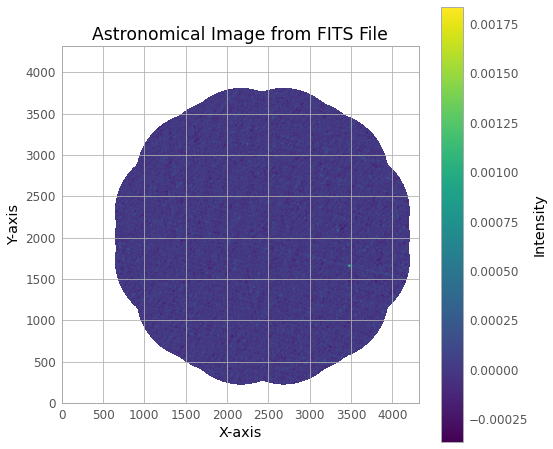

In [126]:
from astropy.visualization import astropy_mpl_style, imshow_norm
import matplotlib.pyplot as plt

# Use the astropy_mpl_style for a nicer plot
plt.style.use(astropy_mpl_style)

# Open the FITS file
with fits.open(fits_file) as hdul:
    # Access the image data
    data = hdul[0].data[0,:,:]

    # Display the image using matplotlib
    plt.figure(figsize=(8, 8))
    plt.imshow(data, cmap='viridis', origin='lower')
    plt.colorbar(label='Intensity')
    plt.title('Astronomical Image from FITS File')
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.show()

In [78]:
hdulist=fits.open(fits_file)

In [79]:
hdulist

In [80]:
img=hdulist[0].data

In [142]:
print(img[0])

[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]


In [81]:
img.shape

(97, 4320, 4320)

In [125]:
img[0,:,:]

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)

In [83]:
wcs=WCS(hdulist[0].header)

Set OBSGEO-B to    34.078827 from OBSGEO-[XYZ].
Set OBSGEO-H to     2115.607 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [84]:
wcs

WCS Keywords

Number of WCS axes: 4
CTYPE : 'RA---SIN'  'DEC--SIN'  'FREQ'  'STOKES'  
CRVAL : 53.2275375  31.18750555278  1317672202.08  2.0  
CRPIX : 2161.0  2161.0  1.0  1.0  
PC1_1 PC1_2 PC1_3 PC1_4  : 1.0  0.0  0.0  0.0  
PC2_1 PC2_2 PC2_3 PC2_4  : 0.0  1.0  0.0  0.0  
PC3_1 PC3_2 PC3_3 PC3_4  : 0.0  0.0  1.0  0.0  
PC4_1 PC4_2 PC4_3 PC4_4  : 0.0  0.0  0.0  1.0  
CDELT : -0.0006944444444444  0.0006944444444444  8003843.060951  1.0  
NAXIS : 4320  4320  97

In [85]:
stok=2

In [86]:
for ip in range(len(RA0)):
    print(ip)

0
1
2
3
4
5
6
7
8


In [87]:
ip=0

In [88]:
sky1=[[RA0[ip],DEC0[ip],1.47339395E9,0]]

In [89]:
sky1

[[52.975, 31.0775, 1473393950.0, 0]]

In [90]:
pixcrd2 = wcs.all_world2pix(sky1, 0)

In [91]:
pixcrd2

array([[ 2.47145768e+03,  2.00194754e+03,  1.94558722e+01,
        -2.00000000e+00]])

In [92]:
x0=int(pixcrd2[0][0]+0.5)

In [93]:
print(x0)

2471


In [94]:
y0=int(pixcrd2[0][1]+0.5)

In [95]:
y0

2002

In [96]:
DEC0[ip]

31.0775

In [97]:
if (DEC0[ip]>=0):
    sourcename_RADEC="H%07.3f+%06.3f"  % (int(1.E3*RA0[ip])/1000.,int(1.E3*DEC0[ip])/1000.)
else:  
    sourcename_RADEC="H%07.3f%06.3f"  % (int(1.E3*RA0[ip])/1000.,int(1.E3*DEC0[ip])/1000.)

In [98]:
sourcename_RADEC

'H052.975+31.077'

In [108]:
spectrum_file = "%s_%s_%s_%s.pro" % (sourcename_RADEC, dx, dy, stokes)

In [109]:
spectrum_file

'H052.975+31.077_4_4_Q.pro'

In [110]:
OUT=open(path+'/Images/img'+str(nit)+'/RMsyn/'+spectrum_file,"w")

In [111]:
OUT

<_io.TextIOWrapper name='../data/19B-053_2019_12_15_T07_36_56.546/products/Images/img20000/RMsyn/H052.975+31.077_4_4_Q.pro' mode='w' encoding='UTF-8'>

In [113]:
print("Pixel coordinates: ",x0,y0,sourcename_RADEC,spectrum_file)

Pixel coordinates:  2471 2002 H052.975+31.077 H052.975+31.077_4_4_Q.pro


In [115]:
print("## RA DEC: ",RA0[ip],DEC0[ip], file=OUT)

In [116]:
print("## Pixel coordinates: ",x0,y0,"  Box : %d  %d" % (dx,dy), file=OUT)

In [117]:
print("## Source name: ",sourcename_RADEC," Stokes ",stokes, file=OUT)

In [118]:
print("## Spectrum file: ",spectrum_file, file=OUT)

In [119]:
print("##  ", file=OUT)

In [120]:
box_spectrum=img[:,(y0-dy):(y0+dy),(x0-dx):(x0+dx)]

In [ ]:
img[:,x0, (0)]

In [160]:
mean_spectrum=img[:,x0,y0]

In [161]:
mean_spectrum

array([-4.14355054e-05, -4.14355054e-05, -7.01234676e-05,  9.77359887e-05,
       -3.46700872e-05,  1.56590249e-05, -1.86924353e-05,  2.07126886e-05,
       -1.79740164e-05,  1.22784013e-05,  2.15449854e-05,  3.14729186e-05,
       -3.64411426e-05, -7.25514037e-05,  2.40083991e-05,  3.71698343e-06,
        5.00088863e-05,  8.62282686e-05,  1.48737836e-05,  2.53257458e-05,
       -1.86545021e-05,  6.75434203e-05,  4.52332388e-05,  6.43327949e-05,
       -2.64255432e-05,  0.00000000e+00, -1.47628498e-05, -3.59608712e-05,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  1.00000002e+30,  1.00000002e+30,  1.00000002e+30,
        1.00000002e+30,  1.00000002e+30,  1.00000002e+30,  1.00000002e+30,
        1.00000002e+30,  0.00000000e+00, -2.91098913e-05, -2.93934172e-05,
        6.32429374e-06, -1.46014700e-05,  1.74033073e-06, -1.87965430e-04,
       -1.04247905e-04,  3.02223401e-04, -2.10535472e-05,  4.43297586e-06,
       -1.58825733e-05,  

In [162]:
freq=np.copy(mean_spectrum)

In [163]:
freq

array([-4.14355054e-05, -4.14355054e-05, -7.01234676e-05,  9.77359887e-05,
       -3.46700872e-05,  1.56590249e-05, -1.86924353e-05,  2.07126886e-05,
       -1.79740164e-05,  1.22784013e-05,  2.15449854e-05,  3.14729186e-05,
       -3.64411426e-05, -7.25514037e-05,  2.40083991e-05,  3.71698343e-06,
        5.00088863e-05,  8.62282686e-05,  1.48737836e-05,  2.53257458e-05,
       -1.86545021e-05,  6.75434203e-05,  4.52332388e-05,  6.43327949e-05,
       -2.64255432e-05,  0.00000000e+00, -1.47628498e-05, -3.59608712e-05,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  1.00000002e+30,  1.00000002e+30,  1.00000002e+30,
        1.00000002e+30,  1.00000002e+30,  1.00000002e+30,  1.00000002e+30,
        1.00000002e+30,  0.00000000e+00, -2.91098913e-05, -2.93934172e-05,
        6.32429374e-06, -1.46014700e-05,  1.74033073e-06, -1.87965430e-04,
       -1.04247905e-04,  3.02223401e-04, -2.10535472e-05,  4.43297586e-06,
       -1.58825733e-05,  

In [164]:
flag=np.copy(mean_spectrum)*0.0

In [165]:
flag

array([-0., -0., -0.,  0., -0.,  0., -0.,  0., -0.,  0.,  0.,  0., -0.,
       -0.,  0.,  0.,  0.,  0.,  0.,  0., -0.,  0.,  0.,  0., -0.,  0.,
       -0., -0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0., -0., -0.,  0., -0.,  0., -0., -0.,  0., -0.,  0.,
       -0.,  0., -0., -0., -0., -0., -0., -0.,  0.,  0.,  0., -0., -0.,
       -0.,  0.,  0.,  0., -0., -0., -0., -0.,  0., -0., -0.,  0.,  0.,
       -0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
       -0., -0.,  0., -0., -0., -0.], dtype=float32)

In [166]:
flag[np.isnan(flag)]=0.0

In [167]:
flag

array([-0., -0., -0.,  0., -0.,  0., -0.,  0., -0.,  0.,  0.,  0., -0.,
       -0.,  0.,  0.,  0.,  0.,  0.,  0., -0.,  0.,  0.,  0., -0.,  0.,
       -0., -0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0., -0., -0.,  0., -0.,  0., -0., -0.,  0., -0.,  0.,
       -0.,  0., -0., -0., -0., -0., -0., -0.,  0.,  0.,  0., -0., -0.,
       -0.,  0.,  0.,  0., -0., -0., -0., -0.,  0., -0., -0.,  0.,  0.,
       -0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
       -0., -0.,  0., -0., -0., -0.], dtype=float32)

In [168]:
len(mean_spectrum)

97

In [180]:
sky=wcs.all_pix2world([[x0,y0,0,stok]],4)

In [181]:
sky

array([[5.29786216e+01, 3.10747657e+01, 1.28565683e+09, 0.00000000e+00]])

In [182]:
freq[0]=sky[0][2]

In [183]:
freq[0]

1285656800.0

In [186]:
mean_spectrum[0]=np.average(box_spectrum[0,:,:])

In [203]:
mean_spectrum[0]

2.1923752e-05

In [205]:
deltax = 10
deltay = 10
deltaxy = 7

background_1 = img[0,y0, (x0+deltay)]
background_2 = img[0,y0, (x0-deltay)]
background_3 = img[0,(y0+deltax), x0]
background_4 = img[0,(y0-deltax), x0]
background_5 = img[0,(y0+deltax), (x0+deltay)]
background_6 = img[0,(y0+deltax), (x0-deltay)]
background_7 = img[0,(y0-deltax), (x0-deltay)]
background_8 = img[0,(y0-deltax), (x0+deltay)]

In [208]:
print (f"Backgrounds:{background_1},{background_2},{background_3},{background_4},{background_5},{background_6},{background_7},{background_8}")

Backgrounds:3.255671981605701e-05,-1.4443964573729318e-05,-4.44329998572357e-05,-5.5549175158375874e-05,-5.074433647678234e-05,-2.6277855795342475e-05,-0.0001508342393208295,1.5638815966667607e-06


In [187]:
mean_spectrum[0]

2.1923752e-05

In [215]:
diff = mean_spectrum[0]-[background_1,background_2,background_3,background_4,
        background_5,background_6,background_7,background_8]

In [216]:
diff

array([-1.0632968e-05,  3.6367717e-05,  6.6356748e-05,  7.7472927e-05,
        7.2668088e-05,  4.8201608e-05,  1.7275799e-04,  2.0359870e-05],
      dtype=float32)

In [218]:
np.mean(diff)

6.0443996e-05

In [194]:
if (mean_spectrum[0]>1.E10):
    # If in here, found at least some pixels with BLANK vale 1.E30
    # Discard the whole channel. Set flag array value to 1.
    mean_spectrum[0]=0
    flag[ispec]=1.
    print("%15.12e  %15.8e  %d" % (freq[ispec],mean_spectrum[ispec],int(flag[ispec]+0.5)), file=OUT)

In [ ]:
ispec=0
for ispec in range(len(mean_spectrum)):
    # Get ferquency of channel:
    # I have to change th 4th index
    sky=wcs.all_pix2world([[x0,y0,ispec,stok]],0)
    freq[ispec]=sky[0][2]

    # Average over the box:
    mean_spectrum[ispec]=np.average(box_spectrum[ispec,:,:])
    if (mean_spectrum[ispec]>1.E10):
        # If in here, found at least some pixels with BLANK vale 1.E30
        # Discard the whole channel. Set flag array value to 1.
        mean_spectrum[ispec]=0
        flag[ispec]=1.
    print("%15.12e  %15.8e  %d" % (freq[ispec],mean_spectrum[ispec],int(flag[ispec]+0.5)), file=OUT)

In [195]:
OUT.close()

In [6]:
import sys
sys.path.append('.')
from configs import path, nit, threedigits, thresh
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
import math
import pandas as pd

pblim = 0.06

dx=4
dy=4

#546
path = '../data/19B-053_2019_12_15_T07_36_56.546/products'
refant_name = 'ea24'
phase_center = 'J2000 03:32:04.530001 +31.05.04.00000'
thresh = '1e-4'
nit = 20000
threedigits ='546'
pblim = 0.06

deltax = 10
deltay = 10
deltaxy = 7


Stokes = [
        'I',
        'Q',
        'U'
        ]

manual_setting=1


def ra_dec_to_degrees(ra, dec):
    ra = ra.split(':')
    ra_hours = int(ra[0])
    ra_minutes = int(ra[1])
    ra_seconds = int(ra[2])

    dec = dec.split(':')
    dec_degrees = int(dec[0])
    dec_minutes = int(dec[1])
    dec_seconds = int(dec[2])
    # Convert RA to degrees
    ra_degrees = (ra_hours + ra_minutes / 60 + ra_seconds / 3600) * 15

    # Convert Dec to degrees
    sign = 1 if dec_degrees >= 0 else -1
    dec_degrees = abs(dec_degrees) + dec_minutes / 60 + dec_seconds / 3600
    dec_degrees *= sign

    return ra_degrees, dec_degrees

#----------------------------------------------------------------
if manual_setting == 1:
    ra_list = ['3:31:54', '3:34:16', '3:33:21', '3:35:05', '3:31:19', '3:30:09', '3:28:40', '3:32:41', '3:34:01']
    dec_list = ['31:04:39', '31:12:10', '30:55:28', '30:47:04', '30:47:23', '30:32:53', '30:49:56', '30:20:11', '31:18:40']

    ra_list = np.array(ra_list)
    dec_list = np.array(dec_list)

    RA0=[]
    DEC0=[]
    for i in range(ra_list.shape[0]):
        radec=ra_dec_to_degrees(ra_list[i], dec_list[i])
        RA0.append(radec[0])
        DEC0.append(radec[1])


elif manual_setting == 0:   

    imagename= threedigits + '-mosaic-fieldALL-Stokes'+str(Stoke)+'-2.5arc-'+str(nit)+'-'+str(thresh)+'-spwALL-pb'+str(pblim)+'-cyclenit500'

    catalog_name= path +'/Images/'+ imagename + '.image.pybdsf.srl'

    df = pd.read_csv(catalog_name, delim_whitespace=True)

    RA0 = df['RA'].tolist()
    DEC0 = df['DEC'].tolist()
#----------------------------------------------------------------
for stokes in Stokes:
    
    fits_file =path+'/Images/img'+str(nit)+'/Stokes'+stokes+'.fits'
    hdulist=fits.open(fits_file)
    img=hdulist[0].data
    wcs=WCS(hdulist[0].header)
    
    if stokes=='I':
        stok = 1
    if stokes=='Q':
        stok = 2
    if stokes=='U':
        stok = 3        

    for ip in range(len(RA0)):
        sky1=[[RA0[ip],DEC0[ip],1.47339395E9,0]]
        pixcrd2 = wcs.all_world2pix(sky1, 0) 
        print(pixcrd2)

        x0=int(pixcrd2[0][0]+0.5)
        y0=int(pixcrd2[0][1]+0.5)

        if (DEC0[ip]>=0):
            sourcename_RADEC="H%07.3f+%06.3f"  % (int(1.E3*RA0[ip])/1000.,int(1.E3*DEC0[ip])/1000.)
        else:  
            sourcename_RADEC="H%07.3f%06.3f"  % (int(1.E3*RA0[ip])/1000.,int(1.E3*DEC0[ip])/1000.)

        spectrum_file = "%s_%s_%s_%s.pro" % (sourcename_RADEC, dx, dy, stokes)

        OUT=open(path+'/Images/img'+str(nit)+'/RMsyn/'+spectrum_file,"w")

        print("Pixel coordinates: ",x0,y0,sourcename_RADEC,spectrum_file)
        print("## RA DEC: ",RA0[ip],DEC0[ip], file=OUT)
        print("## Pixel coordinates: ",x0,y0,"  Box : %d  %d" % (dx,dy), file=OUT)
        print("## Source name: ",sourcename_RADEC," Stokes ",stokes, file=OUT)
        print("## Spectrum file: ",spectrum_file, file=OUT)
        print("##  ", file=OUT)

        box_spectrum=img[:,(y0-dy):(y0+dy),(x0-dx):(x0+dx)]
        mean_spectrum=img[:,x0,y0]
        freq=np.copy(mean_spectrum)
        

        # Use the array flag to keep track of flagged channels
        flag=np.copy(mean_spectrum)*0.0

        flag[np.isnan(flag)]=0.0

       
        for ispec in range(len(mean_spectrum)):
            # Get ferquency of channel:
            # I have to change th 4th index
            sky=wcs.all_pix2world([[x0,y0,ispec,stok]],0)
            freq[ispec]=sky[0][2]

            # Average over the box:
            mean_spectrum[ispec]=np.average(box_spectrum[ispec,:,:])
            
            
            #Background
            background_1 = img[ispec,x0, (y0+deltay)]
            background_2 = img[ispec,x0, (y0-deltay)]
            background_3 = img[ispec,(x0+deltax), y0]
            background_4 = img[ispec,(x0-deltax), y0]
            background_5 = img[ispec,(x0+deltax), (y0+deltay)]
            background_6 = img[ispec,(x0+deltax), (y0-deltay)]
            background_7 = img[ispec,(x0-deltax), (y0-deltay)]
            background_8 = img[ispec,(x0-deltax), (y0+deltay)]
            print (f"Backgrounds:{background_1},{background_2},{background_3},{background_4},{background_5},{background_6},{background_7},{background_8}")
            
            diff = [background_1,background_2,background_3,background_4,
                    background_5,background_6,background_7,background_8]-mean_spectrum[ispec]
            
            mean_spectrum_reduced = np.median(diff)
            
            if (mean_spectrum_reduced>1.E10):
                # If in here, found at least some pixels with BLANK vale 1.E30
                # Discard the whole channel. Set flag array value to 1.
                mean_spectrum_reduced=0
                flag=1.
            print("%15.12e  %15.8e  %d" % (freq[ispec],mean_spectrum_reduced,int(flag[ispec]+0.5)), file=OUT)


        OUT.close()

    rms=np.std(mean_spectrum)

    if (rms>0.002):
        print(sourcename_RADEC, rms)



[[ 2.47145768e+03  2.00194754e+03  1.94558722e+01 -1.00000000e+00]]
Pixel coordinates:  2471 2002 H052.975+31.077 H052.975+31.077_4_4_I.pro
Backgrounds:-0.000228558958042413,0.0004181390395388007,0.0002453940105624497,-0.0003232721355743706,0.00020638509886339307,0.00040648120921105146,0.00031690095784142613,-0.00026032401365228
Backgrounds:-0.000228558958042413,0.0004181390395388007,0.0002453940105624497,-0.0003232721355743706,0.00020638509886339307,0.00040648120921105146,0.00031690095784142613,-0.00026032401365228
Backgrounds:-0.0003769593604374677,0.0003600213094614446,8.424602128798142e-05,-0.0005574884125962853,0.00017263932386413217,0.00031010163365863264,0.00014307588571682572,-0.0005454891361296177
Backgrounds:-4.3387692130636424e-05,-0.00017166924953926355,-0.00013894104631617665,-0.00023492398031521589,-2.0800721358682495e-06,-0.00013767708151135594,0.000340650585712865,-0.0004148342995904386
Backgrounds:-6.834408122813329e-05,-1.7520094843348488e-05,-0.0002665908250492066,0.

Set OBSGEO-B to    34.078827 from OBSGEO-[XYZ].
Set OBSGEO-H to     2115.607 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


TypeError: 'float' object is not subscriptable

In [2]:
!pwd

/Users/halehhajizadeh/Desktop/VLA-Perseus/scripts
